In [3]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure imports resolve to the shared root utils package, not Models/utils.py
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Models" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sys.modules.pop("utils", None)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1


In [4]:
import pandas as pd

from utils.data import load_clean_citation_dataframe, build_training_dataframe

CHECKPOINTS_PATH = "../data/checkpoints/checkpoints/01_cleaned_data/01_cleaned_data_part_{}.parquet"

# -----------------------------
# Load and basic cleaning from chunked parquet files
# -----------------------------
df = load_clean_citation_dataframe(
    CHECKPOINTS_PATH,
    start=1,
    end=4,
    remove_empty_rows=True,
 )

print("Righe dopo rimozione valori vuoti:", len(df))

# -----------------------------
# Build final training dataframe (positive + negative pairs)
# -----------------------------
df_training = build_training_dataframe(df, seed=42, filter_years=True)
print("Final training dataset:", len(df_training))

Righe dopo rimozione valori vuoti: 78012
Final training dataset: 51598


In [5]:
from utils.data import build_vector_text_columns

working = build_vector_text_columns(df_training, include_authors=True)
X = working.drop(columns=["is_reference_valid", "article_id", "ref_id"], errors="ignore").copy()
y = working["is_reference_valid"].copy()

print("Feature rows:", len(X))
print("Label distribution:")
print(y.value_counts())

Feature rows: 51598
Label distribution:
is_reference_valid
1    32101
0    19497
Name: count, dtype: int64


In [6]:
from utils.feature_extractor import build_classic_ml_matrix

X_model, y_model, feature_extractor, artifacts = build_classic_ml_matrix(
    df_training,
    max_features=256,
    include_authors=True,
 )

print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)
print("Meta columns:", len(artifacts["meta_columns"]))

X_model shape: (51598, 525)
y_model shape: (51598,)
Meta columns: 12


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model,
 )

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (41278, 525) Test: (10320, 525)


              precision    recall  f1-score   support

           0     0.8777    0.8187    0.8472      3900
           1     0.8942    0.9307    0.9121      6420

    accuracy                         0.8884     10320
   macro avg     0.8859    0.8747    0.8796     10320
weighted avg     0.8880    0.8884    0.8875     10320



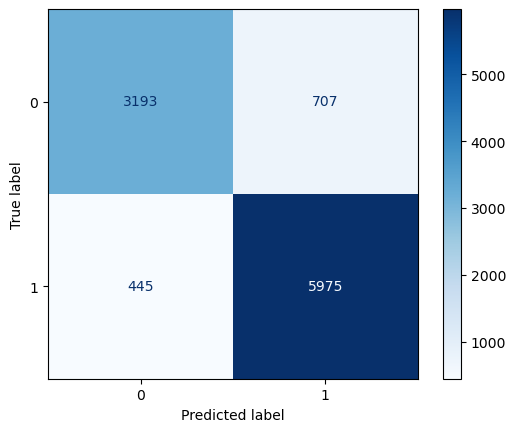

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap="Blues")

In [9]:
import numpy as np

importances = rnd_clf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:]
top_importances = importances[top_idx]

print("Top feature importances (last 20 by index):")
print(top_importances)

Top feature importances (last 20 by index):
[0.00301804 0.0030309  0.00348262 0.00349555 0.0035048  0.00360756
 0.00363242 0.00370623 0.00401307 0.00547794 0.00628846 0.00652284
 0.0068404  0.00700391 0.00732434 0.00778071 0.00939338 0.02332532
 0.11522593 0.2366937 ]


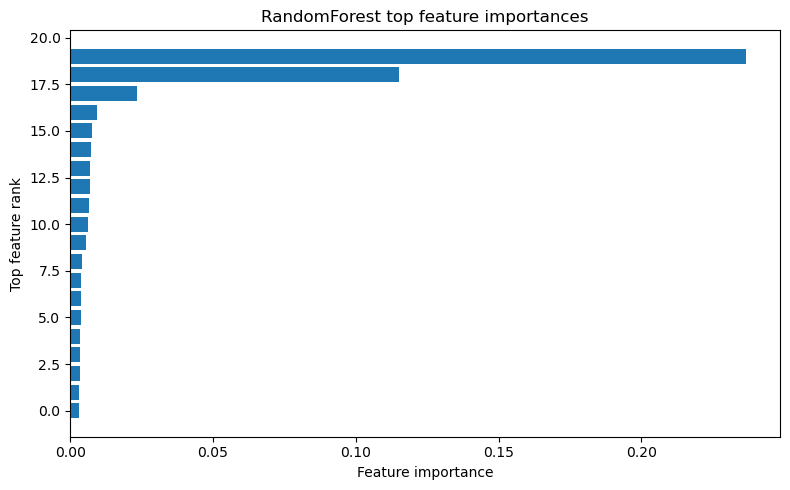

In [10]:
plt.figure(figsize=(8, 5))
plt.barh(range(len(top_importances)), top_importances)
plt.xlabel("Feature importance")
plt.ylabel("Top feature rank")
plt.title("RandomForest top feature importances")
plt.tight_layout()
plt.show()